<!-- GENERATED by scripts/build_problems.py from
     DA4CHE-admin/problems/Topic2.4-High_dimensional_data/master.md
     Do not edit this file directly — your changes will be overwritten.
     Solutions and rubrics live in the private repo and must never appear here. -->

```{contents}
:local:
:depth: 2
```

# Problems: High-dimensional Data

:::{admonition} Get this problem set
:class: seealso

{download}`Download everything (Topic2.4-High_dimensional_data_Problems.zip) <archives/Topic2.4-High_dimensional_data_Problems.zip>` — the notebook and
`solvent_ir_batchA.csv`, in a folder that is ready to run as-is.

The Download badge at the top of the page will also give you the notebook on its own.
On Vocareum everything is already set up for you.
:::

:::{admonition} Before you start
:class: tip

This problem set accompanies {doc}`High-dimensional Data </2-regression/Topic2.4-High_dimensional_data>`. It is worth **100 points**:

- **Part A — Skill Checks (30 pts)** — short answers, auto-graded, resubmit as often as
  you like until they pass.
- **Part B — Visualization (35 pts)** — plots plus written interpretation, peer graded.
- **Part C — Open Ended (35 pts)** — one synthesis problem, peer graded.

The parts build on each other: Part A works out the syntax you need for Part B, and
Part B produces the evidence you argue from in Part C. Do them in order.
:::



## Setup

A solvent-recovery column separates a four-solvent waste stream, and an FTIR spectrometer
watches the overhead vapor so the composition is known without pulling a sample. Every scan
returns 880 numbers. You have 120 scans. That is the situation this chapter is about: far
more measured quantities than measurements.

Those 880 numbers are called **channels**. A spectrometer does not measure absorbance at a
single wavelength but reports it in a series of narrow, evenly spaced wavenumber bins; one
channel is one bin, and a scan is one absorbance reading in each. This instrument's channels
are 4 cm⁻¹ wide and run from 450 to 3966 cm⁻¹, which is where 880 comes from. In the data
they are the 880 columns of `X`, and the column *name* is the wavenumber at the center of the
bin, so "the channel at 1738 cm⁻¹" and "column 322 of `X`" are the same thing.

Most of the questions below are about how the channels relate to *each other* rather than
about any one of them.

The four analytes are **acetone**, **toluene**, ***n*-hexane** and **2-propanol**. The
spectra of all four, and of the two gases that leak into any purge — water vapor and carbon
dioxide — are real measurements taken from the EPA vapor-phase infrared library hosted by
the [NIST Chemistry WebBook, SRD 69](https://webbook.nist.gov/chemistry/). What is simulated
is the mixing: each row is a Beer-Lambert sum of the four analyte spectra at some
composition, on a slowly drifting instrument baseline, with some residual water and CO₂ in
the light path and detector noise on top. The generating model is recorded in full with
the course materials, and the dataset can be rebuilt from the WebBook at any time.

Because the library reports **absorbance** rather than transmittance, absorbances add: a
mixture spectrum is a weighted sum of pure-component spectra, with no log conversion needed.

You do not need to know any infrared spectroscopy to do this set. Everything it assumes is in
this table, which lists where each species in the vapor absorbs. The positions were read off
the reference spectra themselves, so they describe this data rather than a textbook.

| Region [cm⁻¹] | What absorbs there | Which species |
|---|---|---|
| 2850–3000 | C–H stretch | **all four analytes** — every one of them is an organic molecule with C–H bonds |
| 1700–1780 | C=O (carbonyl) stretch | **acetone only**, of the four analytes |
| 3000–3090, and 726 | aromatic C–H and ring bending | toluene |
| 1146, 1382 | C–O stretch and C–H bending | 2-propanol |
| 1500–1600, 3700–3900 | water vapor | not an analyte — it leaks in from the purge gas |
| 2310–2360 | CO₂ | not an analyte — same |

Two rows carry most of the weight. The **2850–3000** band is the largest absorption in the
data and every analyte contributes to it, so knowing the absorbance there tells you how much
organic vapor is present but very little about which one. The **1700–1780** band is the
opposite: among the four analytes only acetone absorbs there. (Water also has absorption in
that region, which is one reason the purge matters.)

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
try:
    plt.style.use('../settings/plot_style.mplstyle')   # available inside the book
except OSError:
    pass                                              # downloaded notebook: use defaults

df = pd.read_csv('data/solvent_ir_batchA.csv')

# Four composition columns, then one column per spectrometer channel. The channel column
# NAMES are the wavenumbers, so the axis for every spectral plot comes from the header.
composition_cols = [c for c in df.columns if c.startswith('x_')]
channel_cols = [c for c in df.columns if c not in composition_cols + ['sample_id']]

wavenumber = np.array([float(c) for c in channel_cols])   # cm^-1, 880 of them
X = df[channel_cols].values                               # (120, 880) absorbance
y = df['x_acetone'].values                                # mole fraction acetone

print(f"X is {X.shape[0]} samples x {X.shape[1]} channels")
print(f"channels span {wavenumber.min():.0f} to {wavenumber.max():.0f} cm^-1, "
      f"spacing {wavenumber[1] - wavenumber[0]:.0f} cm^-1")
print(f"composition columns: {composition_cols}")

X is 120 samples x 880 channels
channels span 450 to 3966 cm^-1, spacing 4 cm^-1
composition columns: ['x_acetone', 'x_toluene', 'x_hexane', 'x_2propanol']


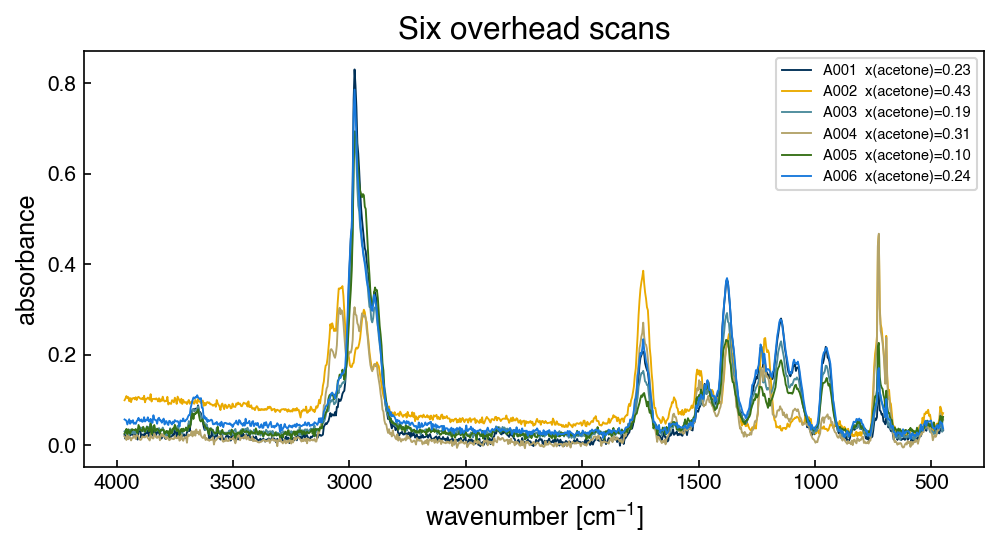

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))
for i in range(6):
    ax.plot(wavenumber, X[i], lw=0.9, label=f'{df.sample_id[i]}  x(acetone)={y[i]:.2f}')
ax.set_xlabel('wavenumber [cm$^{-1}$]')
ax.set_ylabel('absorbance')
ax.set_title('Six overhead scans')
ax.invert_xaxis()                 # IR spectra are drawn with wavenumber decreasing
ax.legend(fontsize=7);

Six scans at six different compositions, and they look very much alike.

Run this once. It defines the `check` helper used after each Part A answer. It will
not run inside the book — use the downloaded notebook.

In [ ]:
# Run this once. It defines `check`, used after each Part A answer below.
import hashlib

_EXPECTED = {
    'q1': (4, ['18ace89e6159', 'e40bc33f147c', 'aec4ec0c194d', '61770e67c27e', 'd4ec56e89b40']),
    'q2': (6, ['1984d428eb1e', '32c64f80fe50', 'f994d498d834', 'f0a54ecff7f2', 'ca205cb08e0f', '9f20385e2ce5', 'ed49010b2bfb', '568586e6d613', '06c1e36c3697', 'b7790d527549', '04cbeb739951', '4448234705c8', '0b9e9c8c4c53', '1cdf9c2fe649', 'e8ec1ecc08a4', '5a29b7b1b8eb', '338961d29c95', '95a4953e74a9', '0880989e76da', '686bd54d09f9', '14f673162a99']),
    'q3': (5, ['58cdb1593382', '0a6f9c14b652', 'a3273d721c23', '438b0d4daf99', 'efe5b59f6223', '72ed336fb1e7', '6e3ae2e9e93a', '2c01dd79d66f', 'de67f5e05919']),
}

def check(qid, value):
    """Compare an answer against a stored digest. Practice only -- nothing is recorded."""
    places, digests = _EXPECTED[qid]
    if value is Ellipsis:
        print(f"{qid}: not answered yet")
        return
    got = hashlib.sha256(f"{float(value):.{places}f}".encode()).hexdigest()[:12]
    print(f"{qid}: {'correct' if got in digests else 'not the expected value'}")

---

## Part A — Skill Checks (30 pts)

Three questions, 10 points each. Each asks you to assign a single number to a named
variable. Run the check cell after each one; there is no limit on attempts.

A1 counts how many independent directions the data actually has, A2 finds the most redundant
pair of channels, and A3 is about scaling, specifically about fitting the scaler on the
wrong rows.

### A1. How many independent directions are there? (10 pts)

:::{exercise}
:label: pr-reg-spec-rank

`X` has 880 columns. It does not have 880 independent columns.

**Mean-center each channel** by subtracting that channel's mean across the 120 samples, then
report the rank of the centered matrix with `np.linalg.matrix_rank`.

Assign the rank to `rank_centered`.
:::

In [ ]:
# YOUR CODE HERE
rank_centered = ...

In [ ]:
check("q1", rank_centered)

### A2. Find the most redundant pair of channels (10 pts)

:::{exercise}
:label: pr-reg-chan-collin

Build the Pearson correlation matrix **between channels** and find the largest absolute
correlation between two *distinct* channels.

Watch two things. `np.corrcoef` correlates **rows** by default, so you want `np.corrcoef(X.T)`
to get an 880 × 880 matrix of channel-to-channel correlations. And the diagonal is all ones, so
it has to be excluded. Compare only pairs with $i > j$, as the chapter does.

Assign the largest absolute off-diagonal correlation to `r_max`.
:::

In [ ]:
# YOUR CODE HERE
r_max = ...

In [ ]:
check("q2", r_max)

### A3. Scale the features without leaking the test set (10 pts)

:::{exercise}
:label: pr-reg-scale-leak

The chapter warns that a scaler must be fit on the training set alone. This question measures
what that actually costs you.

1. Split with `train_test_split(X, test_size=0.2, random_state=0)`.
2. Fit a `StandardScaler` on the **training** features only.
3. Transform the **test** features with that scaler.
4. Report the largest absolute per-channel mean of the transformed test set.

If scaling had been fit on everything, this number would be smaller, and that is the
information you are not allowed to use. Assign the value to `test_mean_max`.
:::

In [ ]:
# YOUR CODE HERE
test_mean_max = ...

In [ ]:
check("q3", test_mean_max)

---

## Part B — Visualization (35 pts)

Part A returned three numbers about the design matrix. This part looks at the spectra
themselves to see where they come from.

::::{exercise}
:label: pr-reg-spectra-structure

**1. Where the light goes.** Plot the **mean** absorbance across the 120 samples against
wavenumber, and on a second axis (or a second panel) plot the per-channel **standard
deviation**. Mark the channel with the largest mean and the channel with the largest standard
deviation.

Then count the channels whose mean absorbance is below **0.02**. Call these the
*transparent* channels, where essentially nothing absorbs, and report that count and what
fraction of the 880 it is.

In **one sentence**: say what those channels contribute to the measurement.

**2. What the correlation matrix is mostly measuring.** Take every 10th channel (88 of them)
and plot the correlation matrix of that subset as a heatmap with `vmin=-1, vmax=1` and a
diverging colormap, labeling the axes in wavenumber rather than column index.

Using the transparent/absorbing split from task 1, report two numbers: the mean correlation
**among the transparent channels**, and the mean **among the absorbing channels**.

Then put every scan on the same baseline level. Each scan sits at its own vertical offset, so
subtract from each scan the mean of its own transparent channels:

```
X_level = X - X[:, transparent].mean(axis=1, keepdims=True)
```

Re-plot the heatmap from `X_level` beside the first, and report the same two means again.

In **two sentences**: say what the transparent channels have in common before that
subtraction, and what the second heatmap shows that the first does not.

**3. What scaling does to the transparent channels.** Apply a `StandardScaler` to all of `X`
and plot the per-channel standard deviation before and after, against wavenumber, on a
**logarithmic** *y* axis for the "before" curve.

In **two sentences**: say what standardizing does to the transparent channels you counted in
task 1, and whether that is what you want here.
::::

In [ ]:
# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(7, 4))

---

## Part C — Open Ended (35 pts)

Part B showed that most channels are redundant and half of them are empty. One response is
to keep only the channels that track acetone. This part measures what happens when you select
them by their correlation with acetone, and then fixes what it finds.

Everything here uses correlations and array indexing. No regression model is needed.

::::{exercise}
:label: pr-reg-channel-select

**1. Rank the channels by how well they track acetone.** Compute the Pearson correlation
between each of the 880 channels and `y`, and plot $|r|$ against wavenumber. Report the
largest $|r|$ and the wavenumber where it occurs. Then take the **top five** channels and
report their wavenumbers together with the mean $|r|$ *among those five*.

In **one sentence**: say how many independent measurements those five channels give you.

**2. Show how far it goes wrong.** Repeat for the top 10, 20 and 50 channels, reporting for
each the wavenumber range spanned and the mean $|r|$ among the selected channels. One table.

In **one sentence**: say at which $k$ the selection finally reaches a different part of the
spectrum.

**3. Fix it, then choose.** Run this rule, which keeps a channel only if nothing already kept
is a near-duplicate of it:

```
kept = []
for j in order:                        # channels by |r| with y, largest first
    if all(abs(corr[j, m]) < cap for m in kept):
        kept.append(j)
```

Report how many channels survive at `cap` = 0.99, 0.95 and 0.90, and plot the channels kept
at one of those caps on top of the $|r|$ curve from task 1.

Then pick one cap. In **two sentences**: say how many of the 880 channels you would keep and
why, citing your numbers from tasks 2 and 3, and name the one thing you would have to measure
to find out whether that choice was any good.

There is more than one defensible cap. The numbers and the reasoning are graded, not which
cap you land on.
::::

In [ ]:
# YOUR CODE HERE
caps = [0.99, 0.95, 0.90]